In [1]:
import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

# Make the plots look publication-ready
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams.update({
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 16,
    'legend.fontsize': 12,
    'lines.linewidth': 2.5
})

# Define the paths to our compiled grid
CATALOG_PATH = "../outputs/master_grid_catalog.csv"
DATA_PATH = "../outputs/master_grid_data.h5"

In [2]:
import pickle
import pandas as pd
from pathlib import Path

# Point this to your grid directory
grid_dir = Path("../outputs/grid_run") 
pkl_files = list(grid_dir.glob("**/*.pkl"))

if not pkl_files:
    print("❌ No .pkl files found in that directory!")
else:
    # Grab the first file for inspection
    sample_file = pkl_files[0]
    print(f"📂 Opening file: {sample_file}\n" + "="*50)
    
    with open(sample_file, 'rb') as f:
        data = pickle.load(f)
        
    print("🔑 TOP-LEVEL KEYS:")
    print(list(data.keys()), "\n")
    
    # Loop through the dictionary and print the contents
    for key, value in data.items():
        if isinstance(value, pd.DataFrame):
            print(f"📊 COLUMNS IN DATAFRAME '{key}':")
            # Print columns neatly
            cols = value.columns.tolist()
            print(cols, "\n")
            
        elif isinstance(value, dict):
            print(f"📁 KEYS IN NESTED DICTIONARY '{key}':")
            # Print the first few keys so it doesn't flood the output
            keys = list(value.keys())
            if len(keys) > 15:
                print(keys[:15], "... [truncated]\n")
            else:
                print(keys, "\n")

📂 Opening file: ../outputs/grid_run/target/M_9.707_Tirr_1441.3_Tint_424.8_Met_-0.53_Core_33.4_fsed_1.9_kzz_3.7.pkl
🔑 TOP-LEVEL KEYS:
['status', 'timestamp', 'parameters', 'iterations', 'profile', 'atmosphere_raw', 'interior_raw'] 

📁 KEYS IN NESTED DICTIONARY 'parameters':
['iron_fraction', 'debug', 'mass', 'T_int', 'T_irr', 'Met', 'core_mass_earth', 'f_sed', 'kzz', 'g_1bar', 'atmosphere_parameters', 'paths', 'retrieval_parameters', 'z_base', 'Y_ratio'] ... [truncated]

📊 COLUMNS IN DATAFRAME 'profile':
['Pressure_Pa', 'Pressure_bar', 'Radius_m', 'Temperature_K', 'Density_kgm3', 'Gravity_ms2', 'MolarMass_kgmol'] 

📊 COLUMNS IN DATAFRAME 'atmosphere_raw':
['/model_parameters/atmosphere/eddy_mode', '/model_parameters/clouds/fraction', '/model_parameters/clouds/mode', '/model_parameters/clouds/particle_density/H2O', '/model_parameters/clouds/particle_density/KCl', '/model_parameters/clouds/particle_radius/H2O', '/model_parameters/clouds/particle_radius/KCl', '/model_parameters/clouds/refe

In [3]:
# Load the catalog
catalog = pd.read_csv(CATALOG_PATH)

# Display some high-level stats
total_models = len(catalog)
converged = len(catalog[catalog['status'] == 'target_reached'])

print(f"📦 Total Models in Grid: {total_models}")
print(f"✅ Converged Models: {converged} ({(converged/total_models)*100:.1f}%)")
print("-" * 50)

# Show the first 5 rows to see what parameters we have to play with
display(catalog.head())

📦 Total Models in Grid: 8340
✅ Converged Models: 1631 (19.6%)
--------------------------------------------------


,model_id,status,target_mass_Mjup,R_1bar_Rjup,true_mass_Mjup,T_int_dial_K,T_int_true_K,T_irr_K,metallicity,core_mass_Me,...,GAIA_GAIA3.G_flux_Wm2um,GAIA_GAIA3.G_flux_Jy,GAIA_GAIA3.Gbp_flux_Wm2um,GAIA_GAIA3.Gbp_flux_Jy,GAIA_GAIA3.Grp_flux_Wm2um,GAIA_GAIA3.Grp_flux_Jy,TESS_TESS.Red_flux_Wm2um,TESS_TESS.Red_flux_Jy,Kepler_Kepler.K_flux_Wm2um,Kepler_Kepler.K_flux_Jy
0,model_00000,crashed,0.192855,NaN,NaN,741.000198,741.000198,773.881812,-1.923231,26.721508,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,model_00001,crashed,0.241846,NaN,NaN,377.951319,377.951319,1360.026099,1.495560,60.143897,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,model_00002,crashed,0.305251,NaN,NaN,335.341157,335.341157,1219.882520,-1.285821,65.621865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,model_00003,crashed,0.354266,NaN,NaN,335.341157,335.341157,1219.882520,-1.285821,65.621865,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,model_00004,crashed,0.360865,NaN,NaN,635.983088,635.983088,347.915158,-1.606303,95.715323,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
import h5py
import os

def print_hdf5_tree(h5_path, max_models_to_show=1):
    """Prints a beautifully formatted tree of the HDF5 file structure."""
    
    if not os.path.exists(h5_path):
        print(f"❌ File not found: {h5_path}")
        return
        
    file_size_mb = os.path.getsize(h5_path) / (1024 * 1024)
    print(f"🗄️ HDF5 File: {h5_path} ({file_size_mb:.1f} MB)")
    print("=" * 60)
    
    with h5py.File(h5_path, "r") as h5f:
        model_keys = list(h5f.keys())
        print(f"📦 Total Models Stored: {len(model_keys)}\n")
        
        # We only want to print the deep structure for the first few models so we don't spam the notebook
        for i, model_id in enumerate(model_keys[:max_models_to_show]):
            print(f"🪐 {model_id}/")
            
            # A recursive function to walk through the folders and print them like a tree
            def print_structure(name, obj):
                # Calculate indentation based on how deep we are in the folders
                depth = name.count('/') + 1 
                indent = "    " * depth
                item_name = name.split('/')[-1]
                
                if isinstance(obj, h5py.Group):
                    print(f"{indent}📁 {item_name}/")
                    
                    # Print any scalar metadata (like strings or single numbers) attached to this folder
                    for attr_name, attr_val in obj.attrs.items():
                        # Truncate really long strings for clean printing
                        val_str = str(attr_val)
                        if len(val_str) > 50:
                            val_str = val_str[:47] + "..."
                        print(f"{indent}    🏷️ {attr_name}: {val_str}")
                        
                elif isinstance(obj, h5py.Dataset):
                    # Print the array name, its dimensions (shape), and data type
                    print(f"{indent}📄 {item_name}  |  Shape: {obj.shape}  |  Type: {obj.dtype}")

            # Trigger the recursive walk for this specific model
            h5f[model_id].visititems(print_structure)
            print("-" * 60)

# Run the function on your master data file
print_hdf5_tree(DATA_PATH)

🗄️ HDF5 File: ../outputs/master_grid_data.h5 (11716.0 MB)
📦 Total Models Stored: 8340

🪐 model_00000/
    📁 parameters/
        🏷️ Met: -1.9232308927077733
        🏷️ T_int: 741.0001976336899
        🏷️ T_irr: 773.881812289453
        🏷️ Y_ratio: 0.2500156674979565
        🏷️ core_mass_earth: 26.721507665758388
        🏷️ debug: False
        🏷️ f_sed: 5.56173893873281
        🏷️ g_1bar: 5.474655914988665
        🏷️ iron_fraction: 0.33
        🏷️ kzz: 1.6453164687479886
        🏷️ mass: 0.19285487435098142
        🏷️ z_base: 0.004426800081383964
------------------------------------------------------------


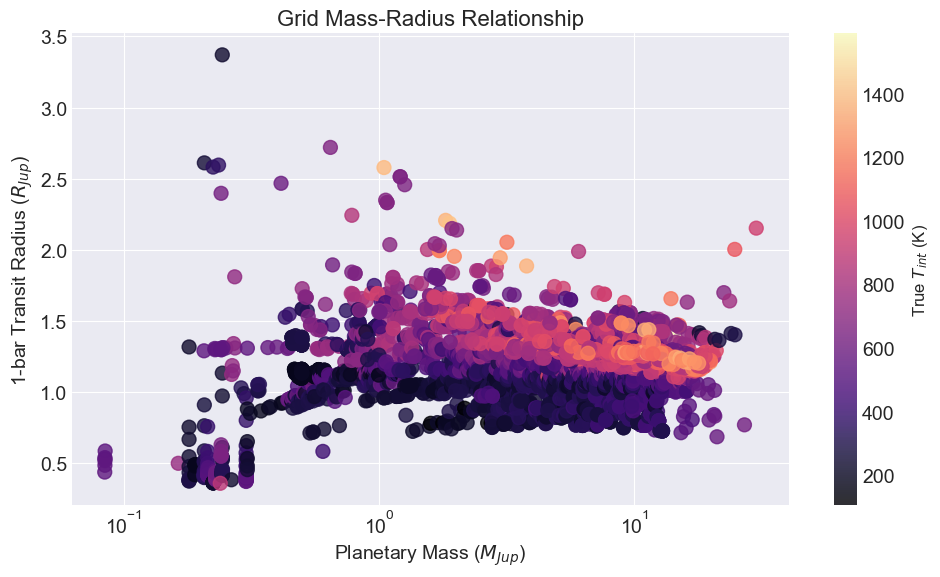

In [5]:
# Filter out crashed runs, but keep all physically valid planets!
valid_models = catalog[catalog['status'].isin(['target_reached', 'max_iterations_reached'])].copy()

fig, ax = plt.subplots(figsize=(10, 6))

# Create a scatter plot using the TRUE 1-bar radius, colored by measured T_int
scatter = ax.scatter(
    valid_models['true_mass_Mjup'], 
    valid_models['R_1bar_Rjup'],      
    c=valid_models['T_int_true_K'], 
    cmap='magma', 
    s=100, 
    edgecolor=None,
    alpha=0.8
)

ax.set_xlabel(r"Planetary Mass ($M_{Jup}$)", fontsize=14)
ax.set_ylabel(r"1-bar Transit Radius ($R_{Jup}$)", fontsize=14)
ax.set_title("Grid Mass-Radius Relationship", fontsize=16)
ax.set_xscale('log')

# Add a colorbar
cbar = plt.colorbar(scatter)
cbar.set_label(r"True $T_{int}$ (K)", fontsize=12)

plt.tight_layout()
plt.show()

In [6]:
# --- Corrected Cell 4: Filtering for a Specific Planet Family ---

# Define our target slice using the NEW status names
mask = (
    (catalog['status'].isin(['target_reached', 'max_iterations_reached', 'converged'])) &
    (np.isclose(catalog['target_mass_Mjup'], 0.5, atol=0.1)) &
    (np.isclose(catalog['metallicity'], 0.0, atol=0.05)))

family_matches = catalog[mask].sort_values(by='T_int_true_K')

# This print statement is your sanity check! It should NOT be 0.
print(f"🔍 Found {len(family_matches)} models matching this exact architecture.")

display(family_matches[['model_id', 'status', 'T_int_true_K', 'R_total_m']])

🔍 Found 131 models matching this exact architecture.


,model_id,status,T_int_true_K,R_total_m
341,model_00341,max_iterations_reached,184.829641,8.099477e+07
339,model_00339,max_iterations_reached,184.829641,8.099477e+07
338,model_00338,max_iterations_reached,184.829641,8.099477e+07
340,model_00340,max_iterations_reached,184.829641,8.099477e+07
312,model_00312,max_iterations_reached,184.829641,7.937310e+07
...,...,...,...,...
574,model_00574,max_iterations_reached,343.020157,1.057373e+08
564,model_00564,max_iterations_reached,343.020157,1.045690e+08
565,model_00565,max_iterations_reached,343.020157,1.045690e+08
561,model_00561,max_iterations_reached,371.295870,1.044382e+08


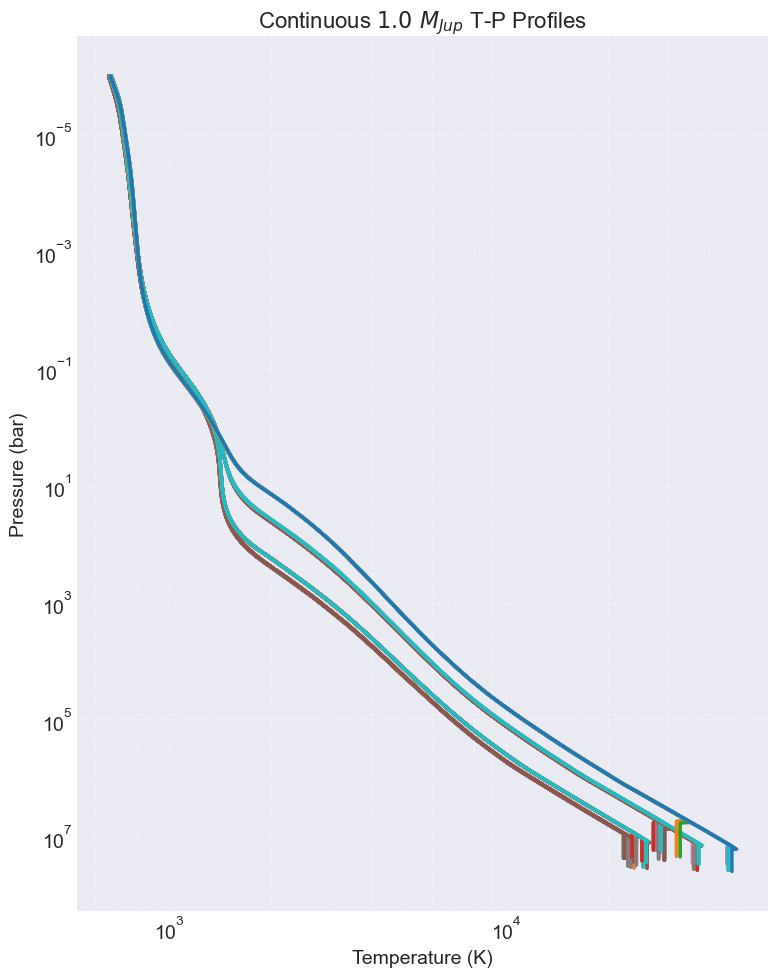

In [7]:
fig, ax = plt.subplots(figsize=(8, 10))

# Open the HDF5 binary store in read-only mode
with h5py.File(DATA_PATH, "r") as h5f:
    
    plotted_any = False
    
    for index, row in family_matches.iterrows():
        model_id = row['model_id']
        t_int = row['T_int_true_K']
        
        # 1. Make sure the model ID exists
        if model_id not in h5f:
            continue
            
        model_grp = h5f[model_id]
        
        # 2. Smartly detect whether the folder is named 'profile' or 'stitched_profile'
        if 'profile' in model_grp:
            prof_name = 'profile'
        elif 'stitched_profile' in model_grp:
            prof_name = 'stitched_profile'
        else:
            print(f"⚠️ {model_id} has no profile folder. I see: {list(model_grp.keys())}")
            continue
            
        # 3. Dynamically find the Pressure and Temperature keys inside that folder
        available_columns = list(model_grp[prof_name].keys())
        p_keys = [k for k in available_columns if 'press' in k.lower()]
        t_keys = [k for k in available_columns if 'temp' in k.lower()]
        
        if not p_keys or not t_keys:
            print(f"⚠️ {model_id} missing P/T arrays. I see: {available_columns}")
            continue
            
        # 4. Extract the arrays using the auto-detected folder and column names
        pressure = model_grp[f"{prof_name}/{p_keys[0]}"][:]
        temperature = model_grp[f"{prof_name}/{t_keys[0]}"][:]
        
        # Auto-convert Pressure to Bar if it was saved in Pascals (values > 10,000)
        if pressure.max() > 1e4:
            pressure = pressure / 1e5
            
        # Plot them!
        ax.plot(temperature, pressure, lw=2.5, label=f"$T_{{int}}$ = {t_int:.0f} K")
        plotted_any = True

if plotted_any:
    ax.set_yscale('log')
    ax.invert_yaxis()
    ax.set_xlabel("Temperature (K)", fontsize=14)
    ax.set_ylabel("Pressure (bar)", fontsize=14)
    ax.set_title(r"Continuous $1.0\ M_{Jup}$ T-P Profiles", fontsize=16)
    ax.set_xscale('log')
    
    # Only show legend if there aren't too many lines
    if len(family_matches) <= 15:
        ax.legend(loc="upper right")
        
    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()
else:
    print("\n❌ Nothing was plotted. Please check the warnings above!")

✅ Found 131 models for the Mass=0.5, Met=0.0 family!
⚠️ Model model_05990 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05989 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05991 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05992 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05993 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05996 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05995 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_05994 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_06001 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_06002 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_06003 does not contain spectral arrays inside the photometry folder.
⚠️ Model model_06004 do

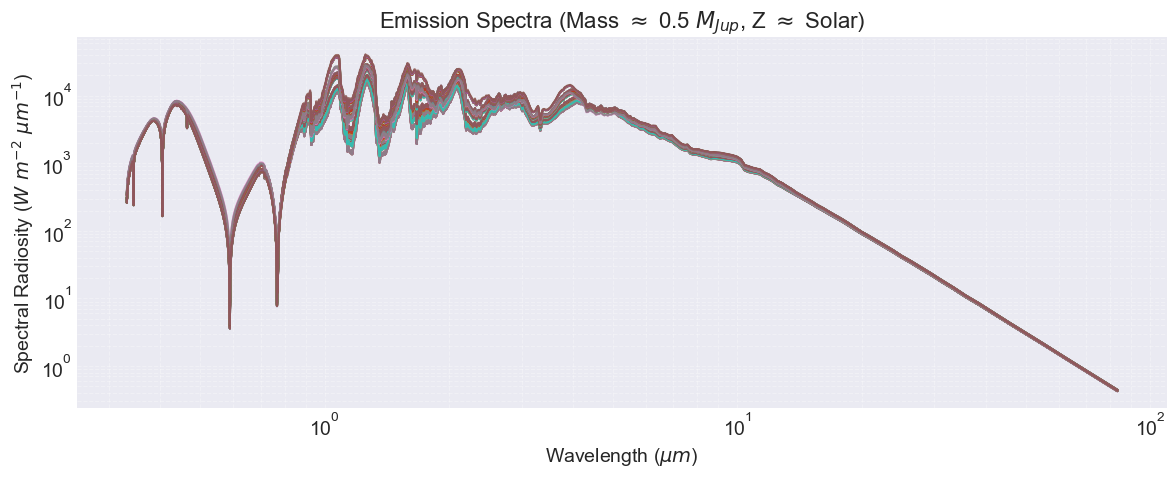

In [8]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np

# --- 2. Define the 'family_matches' Filter ---
# Example: Let's isolate all successful runs for a 1.0 M_Jup planet at Solar Metallicity (0.0)
target_mass = 0.5
target_met = 0.0

family_matches = catalog[
    (catalog['status'].isin(['target_reached', 'max_iterations_reached', 'converged'])) &
    (np.isclose(catalog['target_mass_Mjup'], target_mass, atol=0.05)) &
    (np.isclose(catalog['metallicity'], target_met, atol=0.05))
].copy()

# Sort them by T_int so the legend looks clean
family_matches = family_matches.sort_values(by='T_int_true_K')

print(f"✅ Found {len(family_matches)} models for the Mass={target_mass}, Met={target_met} family!")

# --- 3. The Plotting Routine ---
fig, ax = plt.subplots(figsize=(12, 5))

with h5py.File(DATA_PATH, "r") as h5f:
    
    plotted_any = False
    
    for index, row in family_matches.iterrows():
        model_id = row['model_id']
        t_int = row['T_int_true_K']
        
        try:
            # Note: We now look inside Folder 5!
            phot_grp = h5f[f"{model_id}/photometry"]
            
            # Extract Wavelength and Flux 
            wavelength = phot_grp["wavelength_um"][:]
            flux = phot_grp["emission_flux_W_m2_um"][:]
            
            # Sort for clean plotting
            idx = np.argsort(wavelength)
            
            ax.plot(wavelength[idx], flux[idx], lw=1.5, alpha=0.8, label=f"$T_{{int}}$ = {t_int:.0f} K")
            plotted_any = True
            
        except KeyError:
            print(f"⚠️ Model {model_id} does not contain spectral arrays inside the photometry folder.")

if plotted_any:
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.set_xlabel(r"Wavelength ($\mu m$)", fontsize=14)
    ax.set_ylabel(r"Spectral Radiosity ($W\ m^{-2}\ \mu m^{-1}$)", fontsize=14)
    ax.set_title(f"Emission Spectra (Mass $\\approx$ {target_mass} $M_{{Jup}}$, Z $\\approx$ Solar)", fontsize=16)
    
    # Only show legend if the plot isn't too crowded
    if len(family_matches) <= 15:
        ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5))

    plt.grid(True, which="both", ls="--", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("❌ No spectra were plotted.")

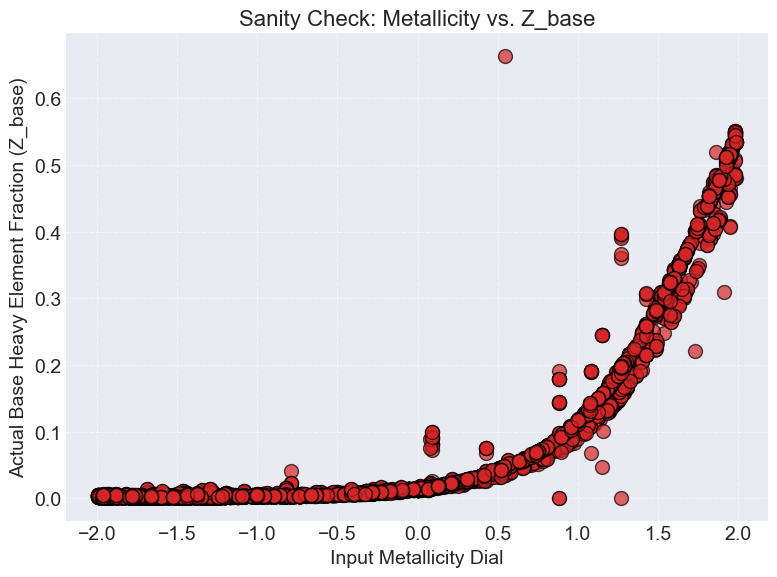

In [9]:
import h5py
import matplotlib.pyplot as plt
import numpy as np

# Filter for all valid models
valid_models = catalog[catalog['status'].isin(['target_reached', 'max_iterations_reached'])].copy()

z_base_values = []
metallicity_values = []

# Open the HDF5 file to extract the exact z_base used for each model
with h5py.File(DATA_PATH, "r") as h5f:
    for index, row in valid_models.iterrows():
        model_id = row['model_id']
        met = row['metallicity']
        
        try:
            # Safely grab z_base from the parameters attributes
            z_base = h5f[f"{model_id}/parameters"].attrs.get('z_base', np.nan)
        except KeyError:
            z_base = np.nan
            
        z_base_values.append(z_base)
        metallicity_values.append(met)

# Add it to our dataframe for plotting
valid_models['z_base'] = z_base_values

# Now let's plot it to see if the dial actually moved!
fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    valid_models['metallicity'], 
    valid_models['z_base'], 
    c='tab:red', 
    s=100, 
    edgecolor='black',
    alpha=0.7
)

ax.set_xlabel("Input Metallicity Dial", fontsize=14)
ax.set_ylabel("Actual Base Heavy Element Fraction (Z_base)", fontsize=14)
ax.set_title("Sanity Check: Metallicity vs. Z_base", fontsize=16)

plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

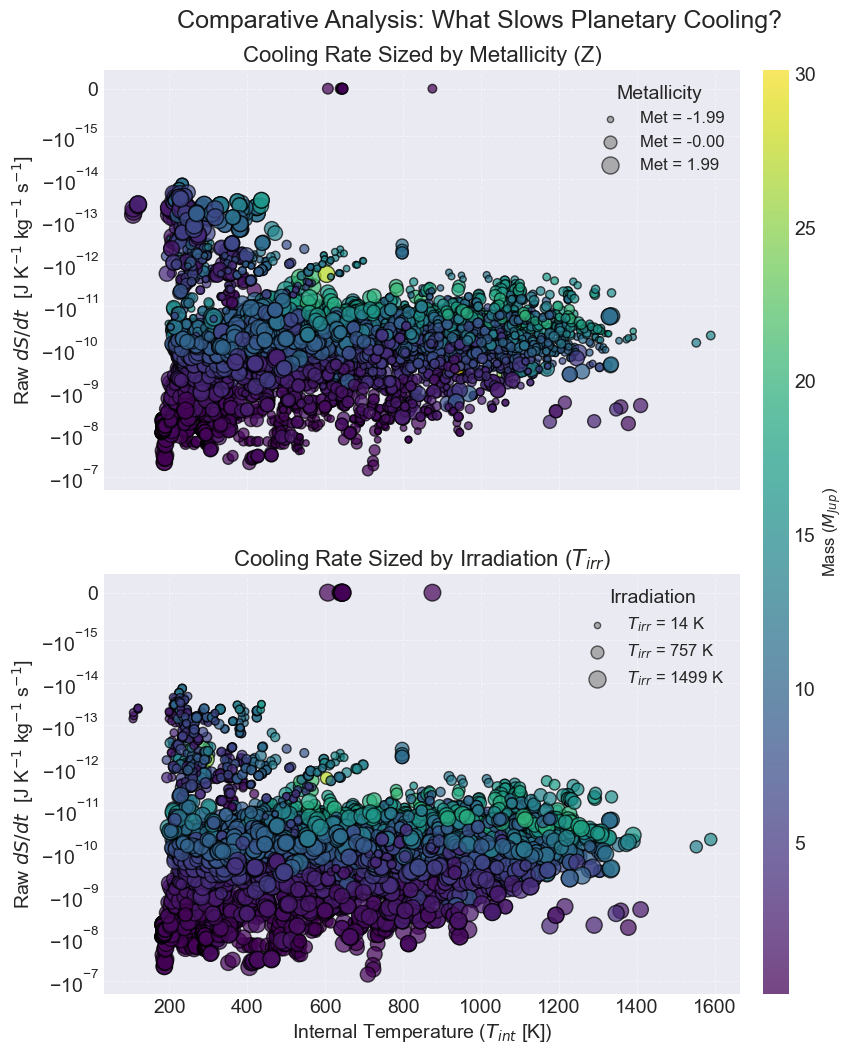

In [10]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../outputs/master_grid_data.h5"

rows = []

# 1. Extract all needed properties in a single pass
with h5py.File(DATA_PATH, "r") as h5f:
    for model_id in h5f.keys():
        try:
            params = h5f[f"{model_id}/parameters"].attrs
            int_attrs = h5f[f"{model_id}/interior_raw"].attrs
            
            t_int = params.get("T_int", np.nan)
            mass = params.get("true_mass_Mjup", params.get("mass", np.nan))
            met = params.get("Met", np.nan)
            t_irr = params.get("T_irr", np.nan)
            
            # Raw interior output (seconds per J/K/kg)
            dt_ds_raw = int_attrs.get("dt_ds_total", np.nan)
            
            # Convert to physical cooling rate (J/K/kg per second)
            dsdt = 1.0 / dt_ds_raw if (pd.notna(dt_ds_raw) and dt_ds_raw != 0) else np.nan
            
            rows.append({
                "model_id": model_id,
                "mass_Mjup": mass,
                "T_int": t_int,
                "Met": met,
                "T_irr": t_irr,
                "dsdt": dsdt
            })
        except KeyError:
            continue

diag_df = pd.DataFrame(rows).dropna()

# --- Dynamic Size Mapping ---
# Metallicity Sizing
met_min, met_max = diag_df['Met'].min(), diag_df['Met'].max()
met_range = (met_max - met_min) if met_max != met_min else 1.0
if met_max == met_min:
    sizes_met = np.full(len(diag_df), 60)
else:
    sizes_met = 20 + 130 * ((diag_df['Met'] - met_min) / met_range)

# Irradiation Sizing
tirr_min, tirr_max = diag_df['T_irr'].min(), diag_df['T_irr'].max()
tirr_range = (tirr_max - tirr_min) if tirr_max != tirr_min else 1.0
if tirr_max == tirr_min:
    sizes_tirr = np.full(len(diag_df), 60)
else:
    sizes_tirr = 20 + 130 * ((diag_df['T_irr'] - tirr_min) / tirr_range)

# 2. Setup the Two-Panel Figure (Stacked Vertically)
# sharex=True perfectly aligns the T_int axes top-to-bottom
# sharey=True perfectly aligns the cooling rates
fig, axes = plt.subplots(2, 1, figsize=(10, 12), sharex=True, sharey=True)

# --- PANEL 1: Metallicity (Top) ---
scatter1 = axes[0].scatter(
    diag_df['T_int'], diag_df['dsdt'],  
    c=diag_df['mass_Mjup'], cmap='viridis', 
    alpha=0.7, edgecolor='k', s=sizes_met
)
axes[0].set_ylabel(r"Raw $dS/dt$  [J K$^{-1}$ kg$^{-1}$ s$^{-1}$]", fontsize=14)
axes[0].set_title("Cooling Rate Sized by Metallicity (Z)", fontsize=16)
axes[0].set_yscale('symlog', linthresh=1e-15)
axes[0].grid(True, which="both", ls="--", alpha=0.4)

# Legend for Panel 1
if met_max != met_min:
    legend_met_vals = [met_min, (met_min + met_max) / 2, met_max]
    for val in legend_met_vals:
        dummy_size = 20 + 130 * ((val - met_min) / met_range)
        axes[0].scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                        label=f"Met = {val:.2f}", edgecolor='k')
    axes[0].legend(title="Metallicity", loc="best", framealpha=0.9)

# --- PANEL 2: Irradiation (Bottom) ---
scatter2 = axes[1].scatter(
    diag_df['T_int'], diag_df['dsdt'],  
    c=diag_df['mass_Mjup'], cmap='viridis', 
    alpha=0.7, edgecolor='k', s=sizes_tirr
)
# Only add the X-label to the bottom plot for a clean look
axes[1].set_xlabel(r"Internal Temperature ($T_{int}$ [K])", fontsize=14)
axes[1].set_ylabel(r"Raw $dS/dt$  [J K$^{-1}$ kg$^{-1}$ s$^{-1}$]", fontsize=14)
axes[1].set_title("Cooling Rate Sized by Irradiation ($T_{irr}$)", fontsize=16)
axes[1].set_yscale('symlog', linthresh=1e-15)
axes[1].grid(True, which="both", ls="--", alpha=0.4)

# Legend for Panel 2
if tirr_max != tirr_min:
    legend_tirr_vals = [tirr_min, (tirr_min + tirr_max) / 2, tirr_max]
    for val in legend_tirr_vals:
        dummy_size = 20 + 130 * ((val - tirr_min) / tirr_range)
        axes[1].scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                        label=f"$T_{{irr}}$ = {val:.0f} K", edgecolor='k')
    axes[1].legend(title="Irradiation", loc="best", framealpha=0.9)
else:
    axes[1].scatter([], [], c='gray', alpha=0.6, s=60, label=f"All $T_{{irr}}$ = {tirr_min:.0f} K", edgecolor='k')
    axes[1].legend(title="Irradiation", loc="best", framealpha=0.9)

# --- Global Adjustments ---
# Single colorbar spanning the height of both plots on the right side
cbar = fig.colorbar(scatter2, ax=axes, pad=0.03, aspect=35)
cbar.set_label(r"Mass ($M_{Jup}$)", fontsize=12)

# Adjust title position so it doesn't overlap the top plot
plt.suptitle("Comparative Analysis: What Slows Planetary Cooling?", fontsize=18, y=0.93)

plt.show()

Total models: 8340 | Solar Metallicity models: 471


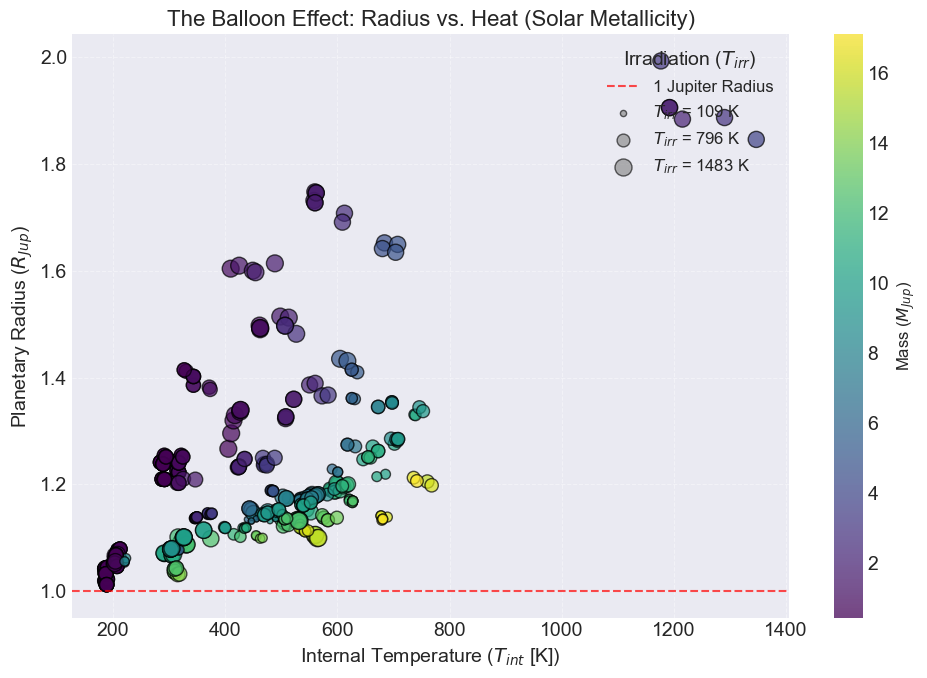

In [11]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = "../outputs/master_grid_data.h5"

# Constants for conversion
G = 6.67430e-11        # Gravitational constant (m^3 kg^-1 s^-2)
M_JUP_KG = 1.898e27    # Jupiter mass in kg
R_JUP_M = 7.1492e7     # Jupiter equatorial radius in meters

rows = []

# 1. Extract data including Metallicity
with h5py.File(DATA_PATH, "r") as h5f:
    for model_id in h5f.keys():
        try:
            params = h5f[f"{model_id}/parameters"].attrs
            
            t_int = params.get("T_int", np.nan)
            mass = params.get("true_mass_Mjup", params.get("mass", np.nan))
            t_irr = params.get("T_irr", np.nan)
            met = params.get("Met", np.nan)
            g_1bar = params.get("g_1bar", np.nan)
            
            if pd.notna(mass) and pd.notna(g_1bar) and g_1bar > 0 and pd.notna(met):
                mass_kg = mass * M_JUP_KG
                radius_m = np.sqrt((G * mass_kg) / g_1bar)
                radius_rjup = radius_m / R_JUP_M
                
                rows.append({
                    "model_id": model_id,
                    "mass_Mjup": mass,
                    "T_int": t_int,
                    "T_irr": t_irr,
                    "Met": met,
                    "Radius_Rjup": radius_rjup
                })
        except KeyError:
            continue

raw_df = pd.DataFrame(rows).dropna()

# --- NEW: Filter for Solar Metallicity ---
# We keep only models where Met is approximately 0.0 (Solar)
solar_df = raw_df[np.abs(raw_df['Met']) <= 0.1].copy()

print(f"Total models: {len(raw_df)} | Solar Metallicity models: {len(solar_df)}")

if solar_df.empty:
    print("⚠️ No models found near solar metallicity (Met ~ 0.0).")
else:
    # --- Dynamic Size Mapping for T_irr ---
    tirr_min = solar_df['T_irr'].min()
    tirr_max = solar_df['T_irr'].max()
    tirr_range = (tirr_max - tirr_min) if tirr_max != tirr_min else 1.0

    if tirr_max == tirr_min:
        sizes_tirr = np.full(len(solar_df), 60)
    else:
        sizes_tirr = 20 + 130 * ((solar_df['T_irr'] - tirr_min) / tirr_range)

    # 2. Plot Radius vs. T_int
    fig, ax = plt.subplots(figsize=(10, 7))

    scatter = ax.scatter(
        solar_df['T_int'], 
        solar_df['Radius_Rjup'],  
        c=solar_df['mass_Mjup'], 
        cmap='viridis', 
        alpha=0.7,
        edgecolor='k',
        s=sizes_tirr
    )

    ax.set_xlabel(r"Internal Temperature ($T_{int}$ [K])", fontsize=14)
    ax.set_ylabel(r"Planetary Radius ($R_{Jup}$)", fontsize=14)
    ax.set_title("The Balloon Effect: Radius vs. Heat (Solar Metallicity)", fontsize=16)

    # Add a reference line for exactly 1 Jupiter Radius
    ax.axhline(1.0, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label="1 Jupiter Radius")

    # Colorbar for Mass
    cbar = plt.colorbar(scatter)
    cbar.set_label(r"Mass ($M_{Jup}$)", fontsize=12)

    # Legend for T_irr Sizes
    if tirr_max != tirr_min:
        legend_tirr_vals = [tirr_min, (tirr_min + tirr_max) / 2, tirr_max]
        for val in legend_tirr_vals:
            dummy_size = 20 + 130 * ((val - tirr_min) / tirr_range)
            ax.scatter([], [], c='gray', alpha=0.6, s=dummy_size, 
                       label=f"$T_{{irr}}$ = {val:.0f} K", edgecolor='k')
        ax.legend(title="Irradiation ($T_{irr}$)", loc="upper right", framealpha=0.9)
    else:
        ax.scatter([], [], c='gray', alpha=0.6, s=60, label=f"All $T_{{irr}}$ = {tirr_min:.0f} K", edgecolor='k')
        ax.legend(title="Irradiation", loc="upper right", framealpha=0.9)

    plt.grid(True, which="both", ls="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

In [14]:
catalog.columns[:20]

Index(['model_id', 'status', 'target_mass_Mjup', 'R_1bar_Rjup',
       'true_mass_Mjup', 'T_int_dial_K', 'T_int_true_K', 'T_irr_K',
       'metallicity', 'core_mass_Me', 'f_sed', 'kzz', 'iterations',
       'P_link_bar', 'R_total_m', 'original_file',
       'JWST_NIRCam.F070W_flux_Wm2um', 'JWST_NIRCam.F070W_flux_Jy',
       'JWST_NIRCam.F090W_flux_Wm2um', 'JWST_NIRCam.F090W_flux_Jy'],
      dtype='object')

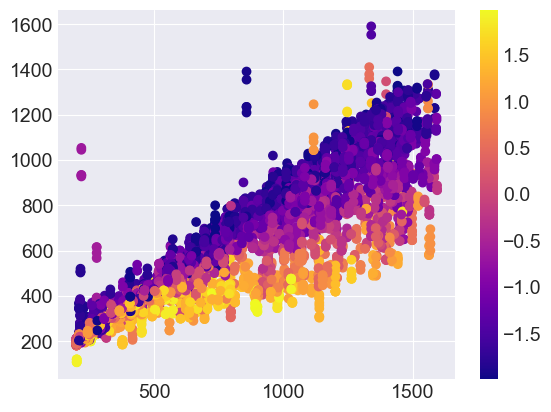

In [18]:
plt.scatter(catalog['T_int_dial_K'],catalog['T_int_true_K'], c=catalog['metallicity'],cmap='plasma')
plt.colorbar()

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
🔍 Found 1822 highly depleted outlier models out of 8328.


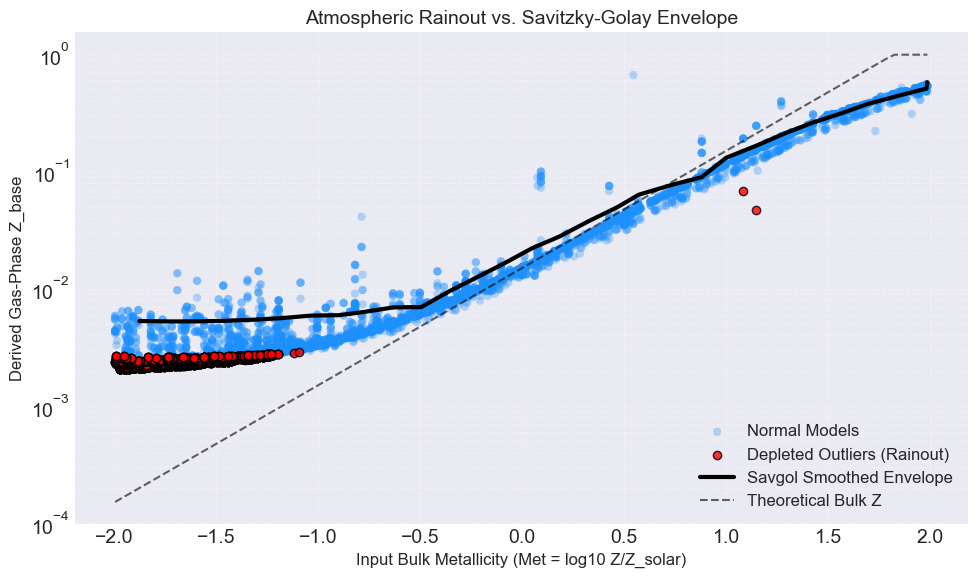


🚀 Extracting the most depleted model: model_03136
   Input Met  : 0.88
   Expected Z : 0.0894
   Actual Z   : 0.0000  <-- Massive depletion!
   T_int      : 768.9 K
   T_irr      : 1495.7 K

Generating diagnostic plot for model_03136...
Figure saved to: ../figures/outlier_model_03136_diagnostics.pdf


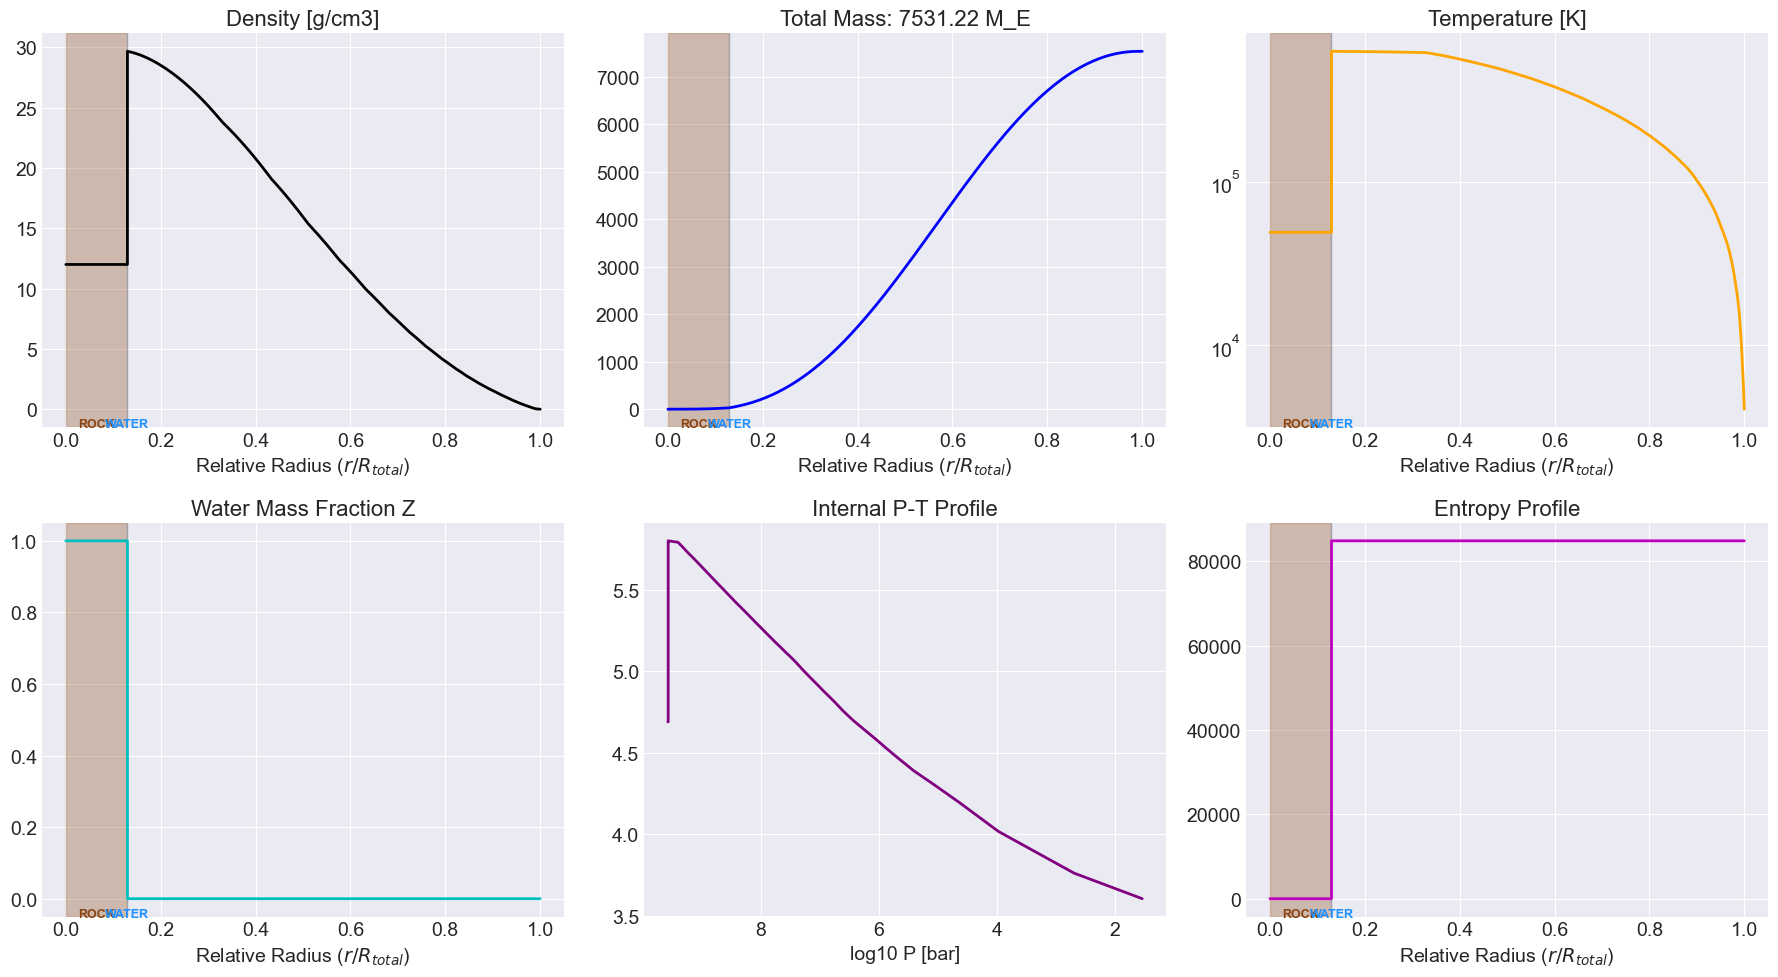

In [39]:
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.signal import savgol_filter
from scipy.interpolate import interp1d

# Assuming you have your plotting tools available
from fuzzycore.plotting import plot_diagnostics

# 1. Path to your compiled master HDF5 file
h5_path = Path("../outputs/master_grid_data.h5")

# 2. Extract Met and z_base for all models
data_rows = []
with h5py.File(h5_path, "r") as h5f:
    for model_id in h5f.keys():
        params = h5f[model_id]['parameters'].attrs
        
        # Only grab models that successfully converged
        if 'interior_raw' in h5f[model_id]: 
            data_rows.append({
                'model_id': model_id,
                'Met': params.get('Met', np.nan),
                'z_base': params.get('z_base', np.nan),
                'T_int': params.get('T_int', np.nan),
                'T_irr': params.get('T_irr', np.nan)
            })

df_analysis = pd.DataFrame(data_rows).dropna()

# 3. Calculate the "Expected" Z_base (Theoretical scaling)
df_analysis['Expected_Z'] = np.clip(0.015 * (10 ** df_analysis['Met']), 0, 0.99)

# =====================================================================
# 3b. Empirical Trend Fitting (Savitzky-Golay Filter)
# =====================================================================
# Group into bins to find the 95th percentile (no-rainout ceiling)
bins = np.linspace(df_analysis['Met'].min(), df_analysis['Met'].max(), 30)
df_analysis['Met_bin'] = np.digitize(df_analysis['Met'], bins)

# Get the upper envelope and sort it to ensure the interpolator works
envelope = df_analysis.groupby('Met_bin')[['Met', 'z_base']].quantile(0.95).dropna().sort_values('Met')

# Determine a safe Savitzky-Golay window length (must be odd and <= len(data))
window = min(11, len(envelope))
if window % 2 == 0: 
    window -= 1

# Apply the Savitzky-Golay filter in log-space
smoothed_log_z = savgol_filter(np.log10(envelope['z_base']), window_length=window, polyorder=2)

# Create an interpolator from the smoothed envelope to map it back to all individual models
envelope_interp = interp1d(envelope['Met'], smoothed_log_z, kind='linear', fill_value="extrapolate")

# Evaluate the fit and ensure it mathematically cannot exceed Z=0.99
df_analysis['Fitted_Z'] = np.clip(10 ** envelope_interp(df_analysis['Met']), 0.0, 0.99)

# =====================================================================
# 4. Find the Outliers
# =====================================================================
# We define an outlier as a model that retains less than 50% of its expected gas-phase metals
df_analysis['Depletion_Ratio'] = df_analysis['z_base'] / df_analysis['Fitted_Z']
outliers = df_analysis[df_analysis['Depletion_Ratio'] < 0.5].sort_values('Depletion_Ratio')

print(f"🔍 Found {len(outliers)} highly depleted outlier models out of {len(df_analysis)}.")

# =====================================================================
# 5. Plot the Trend
# =====================================================================
plt.figure(figsize=(10, 6))

# Plot normal models
normal_models = df_analysis[df_analysis['Depletion_Ratio'] >= 0.5]
plt.scatter(normal_models['Met'], normal_models['z_base'], alpha=0.3, label="Normal Models", c='dodgerblue', edgecolors='none')

# Plot outliers
plt.scatter(outliers['Met'], outliers['z_base'], alpha=0.8, label="Depleted Outliers (Rainout)", c='red', edgecolors='k')

# Plot the Savitzky-Golay smoothed envelope
plt.plot(envelope['Met'], np.clip(10 ** smoothed_log_z, 0, 0.99), 'k-', lw=3, label="Savgol Smoothed Envelope")

# Plot theoretical line for reference
met_range_full = np.linspace(df_analysis['Met'].min(), df_analysis['Met'].max(), 100)
theoretical_curve = np.clip(0.015 * (10 ** met_range_full), 0, 0.99)
plt.plot(met_range_full, theoretical_curve, 'k--', lw=1.5, alpha=0.6, label="Theoretical Bulk Z")

plt.xlabel("Input Bulk Metallicity (Met = log10 Z/Z_solar)", fontsize=12)
plt.ylabel("Derived Gas-Phase Z_base", fontsize=12)
plt.title("Atmospheric Rainout vs. Savitzky-Golay Envelope", fontsize=14)
plt.yscale('log') 
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3, which="both", ls="--")
plt.tight_layout()
plt.show()

# =====================================================================
# 6. Extract and Plot the Worst Outlier
# =====================================================================
if not outliers.empty:
    worst_model = outliers.iloc[0]
    worst_model_id = worst_model['model_id']
    
    print(f"\n🚀 Extracting the most depleted model: {worst_model_id}")
    print(f"   Input Met  : {worst_model['Met']:.2f}")
    print(f"   Expected Z : {worst_model['Fitted_Z']:.4f}")
    print(f"   Actual Z   : {worst_model['z_base']:.4f}  <-- Massive depletion!")
    print(f"   T_int      : {worst_model['T_int']:.1f} K")
    print(f"   T_irr      : {worst_model['T_irr']:.1f} K")
    
    with h5py.File(h5_path, "r") as h5f:
        target_grp = h5f[worst_model_id]
        
        interior_raw = {}
        for key in target_grp['interior_raw'].keys():
            interior_raw[key] = target_grp['interior_raw'][key][:]
        for key in target_grp['interior_raw'].attrs.keys():
            interior_raw[key] = target_grp['interior_raw'].attrs[key]
            
    print(f"\nGenerating diagnostic plot for {worst_model_id}...")
    plot_diagnostics(interior_raw, save_name=f"outlier_{worst_model_id}_diagnostics")

In [41]:
import pickle
import numpy as np
from pathlib import Path
import os

# 1. Point this to the directory containing your converged models
grid_dir = Path("../outputs/grid_run/steps") 
pkl_files = list(grid_dir.glob("*.pkl"))

deleted_count = 0
total_count = len(pkl_files)

print(f"🔍 Scanning {total_count} planetary models for density inversions...")

for pkl_path in pkl_files:
    try:
        with open(pkl_path, 'rb') as f:
            data = pickle.load(f)
            
        # Extract the continuous stitched profile
        profile = data.get('profile', data.get('stitched_profile'))
        
        if profile is not None and not profile.empty:
            # Ensure it is perfectly sorted by pressure (lowest to highest)
            profile = profile.sort_values('Pressure_bar')
            rho = profile['Density_kgm3'].values
            
            # Calculate the change in density between each vertical layer
            d_rho = np.diff(rho)
            
            # Check for inversions. 
            # We use a tiny tolerance (-1e-3) to ensure we don't accidentally 
            # delete good models due to microscopic floating-point math noise.
            if np.any(d_rho < -1e-3):
                # Non-physical inversion detected! Delete the file.
                pkl_path.unlink()  
                deleted_count += 1
                
    except Exception as e:
        print(f"⚠️ Error reading {pkl_path.name}: {e}")

print("-" * 50)
print(f"✅ Cleanup complete!")
print(f"🗑️ Deleted {deleted_count} non-physical models.")
print(f"🌍 Retained {total_count - deleted_count} physically valid models.")

🔍 Scanning 6799 planetary models for density inversions...
--------------------------------------------------
✅ Cleanup complete!
🗑️ Deleted 4509 non-physical models.
🌍 Retained 2290 physically valid models.
